<a href="https://colab.research.google.com/github/jellybbie/study/blob/project3/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('/content/rawdata-spot01fx.xlsx')

In [ ]:
import pandas as pd
df_rs01 = pd.read_excel('/content/rawdata-rs01.xlsx')
display(df_rs01.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6,repeat7,repeat8,repeat9,repeat10
0,Spray TAU-3,5,0,4,3,0,4,4,3,2,0
1,Spray BTH,0,5,2,6,4,1,0,4,0,4
2,Spray MgSO4,3,4,0,0,5,4,0,3,4,5
3,Drench TAU-3,3,4,5,1,5,0,4,0,0,3
4,Drench BTH,3,3,4,0,0,0,1,2,0,0


In [ ]:
df_rs01 = pd.read_excel('/content/rawdata-rs02.xlsx')
display(df_rs01.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6,repeat7,repeat8,repeat9,repeat10
0,Spray TAU-3,5,0,4,3,0,4,4,3,2,0
1,Spray BTH,0,5,2,0,4,1,0,4,0,4
2,Spray MgSO4,3,4,0,0,5,4,0,3,4,5
3,Drench TAU-3,3,4,5,1,5,0,4,0,0,3
4,Drench BTH,3,3,4,0,0,0,1,2,0,0


In [ ]:
df_rs02 = pd.read_excel('/content/rawdata-rs02.xlsx')
display(df_rs02.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6,repeat7,repeat8,repeat9,repeat10
0,Spray TAU-3,5,0,4,3,0,4,4,3,2,0
1,Spray BTH,0,5,2,0,4,1,0,4,0,4
2,Spray MgSO4,3,4,0,0,5,4,0,3,4,5
3,Drench TAU-3,3,4,5,1,5,0,4,0,0,3
4,Drench BTH,3,3,4,0,0,0,1,2,0,0


In [ ]:
# Display basic descriptive statistics for df_rs01
display(df_rs01.describe())

,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6,repeat7,repeat8,repeat9,repeat10
count,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,3.00000,3.333333,3.333333,1.333333,2.500000,1.500000,2.166667,2.666667,1.833333,2.666667
std,1.67332,1.751190,1.966384,1.751190,2.428992,1.974842,2.041241,1.505545,2.228602,2.160247
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.00000,3.250000,2.500000,0.000000,0.250000,0.000000,0.250000,2.250000,0.000000,0.750000
50%,3.00000,4.000000,4.000000,0.500000,2.500000,0.500000,2.500000,3.000000,1.000000,3.500000
75%,3.75000,4.000000,4.750000,2.500000,4.750000,3.250000,4.000000,3.750000,3.500000,4.000000
max,5.00000,5.000000,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,5.000000


In [ ]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Dynamically select 'repeat' columns for df_rs01
repeat_columns_rs01 = [col for col in df_rs01.columns if col.startswith('repeat')]

# Melt the DataFrame to long format
df_melted_rs01 = df_rs01.melt(id_vars=['Treatment'], value_vars=repeat_columns_rs01,
                                var_name='Repeat_Number', value_name='Repeat_Value')

# Convert 'Treatment' to categorical type if not already
df_melted_rs01['Treatment'] = df_melted_rs01['Treatment'].astype('category')

# Create a list of arrays, one for each treatment group
treatment_groups_rs01 = [df_melted_rs01['Repeat_Value'][df_melted_rs01['Treatment'] == t] for t in df_melted_rs01['Treatment'].unique()]

f_statistic_rs01, p_value_rs01 = stats.f_oneway(*treatment_groups_rs01)

print(f"ANOVA F-statistic: {f_statistic_rs01:.2f}")
print(f"ANOVA P-value: {p_value_rs01:.3f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value_rs01 < 0.05:
    print("\nANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...")
    tukey_results_rs01 = pairwise_tukeyhsd(endog=df_melted_rs01['Repeat_Value'], groups=df_melted_rs01['Treatment'], alpha=0.05)
    print(tukey_results_rs01)

    # Generate alphabetical labels for groups that are not significantly different
    tukey_df_rs01 = pd.DataFrame(data=tukey_results_rs01._results_table.data[1:],
                                columns=tukey_results_rs01._results_table.data[0])

    reject_map_rs01 = {}
    for _, row in tukey_df_rs01.iterrows():
        g1, g2, reject = row['group1'], row['group2'], row['reject']
        reject_map_rs01[(g1, g2)] = reject
        reject_map_rs01[(g2, g1)] = reject

    treatments_rs01 = sorted(df_melted_rs01['Treatment'].unique().tolist())
    num_treatments_rs01 = len(treatments_rs01)

    labels_rs01 = {t: set() for t in treatments_rs01}
    current_letter_idx_rs01 = 0

    for i in range(num_treatments_rs01):
        t_i = treatments_rs01[i]
        if not labels_rs01[t_i]:
            current_char = chr(ord('a') + current_letter_idx_rs01)
            labels_rs01[t_i].add(current_char)
            for j in range(num_treatments_rs01):
                t_j = treatments_rs01[j]
                if t_i == t_j:
                    continue
                if not reject_map_rs01.get((t_i, t_j), True):
                    labels_rs01[t_j].add(current_char)
            current_letter_idx_rs01 += 1

    final_labels_rs01 = {t: "".join(sorted(list(l))) for t, l in labels_rs01.items()}

    current_means_rs01 = df_melted_rs01.groupby('Treatment', observed=False)['Repeat_Value'].mean()
    distinct_label_components_rs01 = sorted(list(set("".join(final_labels_rs01.values()))))
    component_ranking_means_rs01 = {}
    for comp in distinct_label_components_rs01:
        treatments_with_comp = [t for t, label_str in final_labels_rs01.items() if comp in label_str]
        means_for_comp = [current_means_rs01[t] for t in treatments_with_comp]
        component_ranking_means_rs01[comp] = max(means_for_comp) if means_for_comp else 0
    sorted_components_rs01 = sorted(component_ranking_means_rs01.items(), key=lambda item: item[1], reverse=True)
    new_letter_map_rs01 = {}
    for idx, (comp, _) in enumerate(sorted_components_rs01):
        new_letter_map_rs01[comp] = chr(ord('A') + idx)
    ranked_final_labels_rs01 = {}
    for treatment, original_label_str in final_labels_rs01.items():
        new_label_chars = []
        for char_comp in original_label_str:
            new_label_chars.append(new_letter_map_rs01[char_comp])
        ranked_final_labels_rs01[treatment] = "".join(sorted(new_label_chars))

    df_melted_rs01['Label'] = df_melted_rs01['Treatment'].map(ranked_final_labels_rs01)

    print("\nOriginal Alphabetical Labels (Tukey HSD):")
    print(final_labels_rs01)
    print("\nRanked Alphabetical Labels (by Mean Value, A=Highest Mean):")
    print(ranked_final_labels_rs01)

else:
    print("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.")
    df_melted_rs01['Label'] = '' # No labels if not significant

ANOVA F-statistic: 1.54
ANOVA P-value: 0.193

ANOVA is not significant (p >= 0.05). No post-hoc test needed.


In [ ]:
# Define the custom treatment order as specified by the user
custom_treatment_order_rs01 = ['Spray TAU-3', 'Spray BTH', 'Spray MgSO4', 'Drench TAU-3', 'Drench BTH', 'Drench MgSO4']


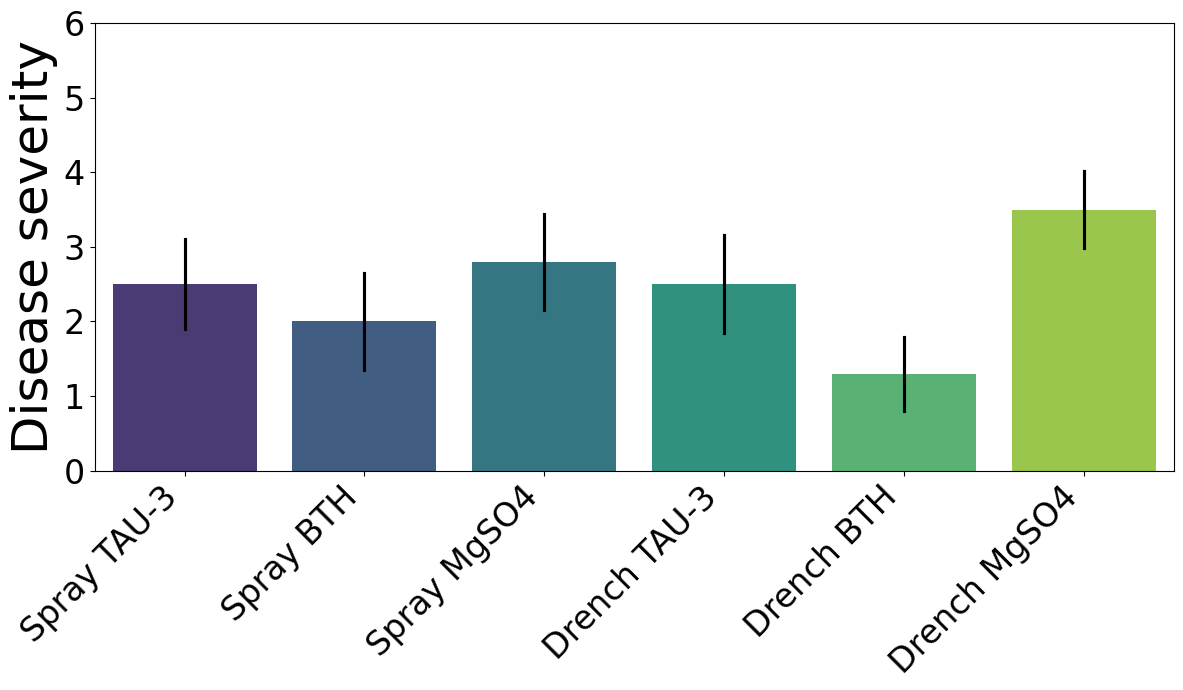

In [ ]:
# Call the create_bar_plot function with the updated df_melted_rs01
create_bar_plot(df_melted_rs01, custom_treatment_order_rs01,
                y_axis_title='Disease severity',
                y_axis_limit=6) # Adjust y-axis limit as needed for this data

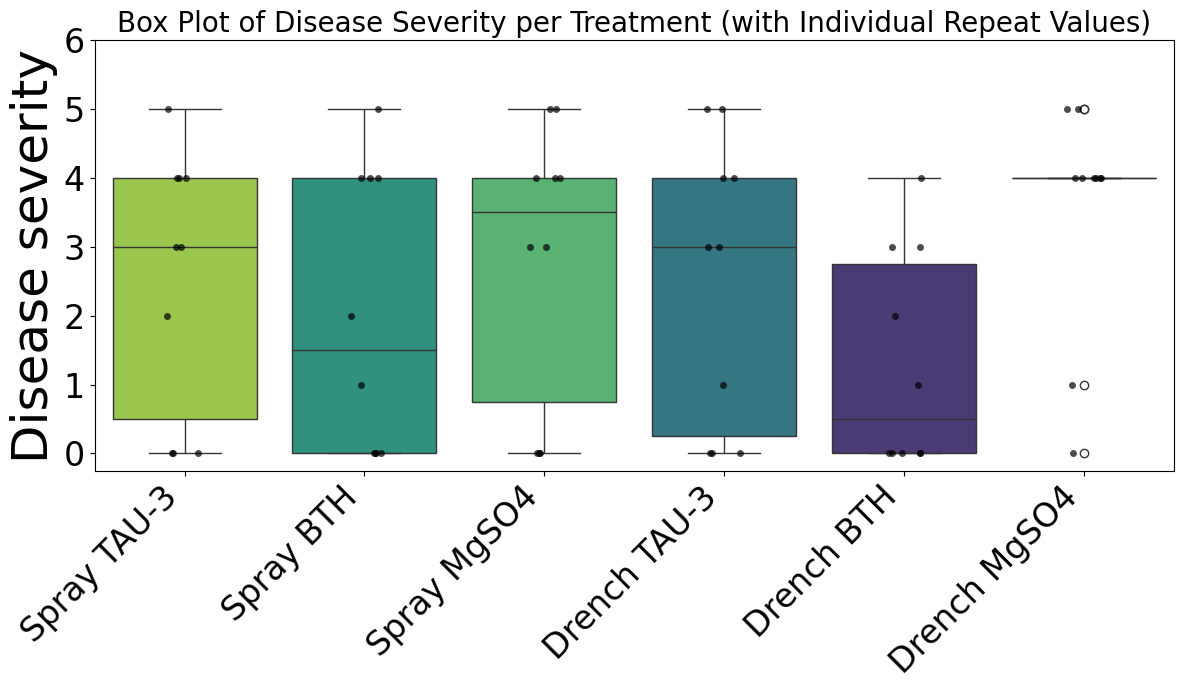

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Create the box plot
sns.boxplot(x='Treatment', y='Repeat_Value', data=df_melted_rs01,
            palette='viridis', order=custom_treatment_order_rs01, hue='Treatment', legend=False)

# Overlay individual data points (stripplot)
sns.stripplot(x='Treatment', y='Repeat_Value', data=df_melted_rs01,
              jitter=True, color='black', size=5, alpha=0.7,
              order=custom_treatment_order_rs01)

plt.xlabel('')
plt.ylabel('Disease severity', fontsize=36)
plt.xticks(rotation=45, ha='right', fontsize=24)
plt.yticks(fontsize=24)
plt.ylim(top=6) # Set y-axis limit consistent with previous plot
plt.title('Box Plot of Disease Severity per Treatment (with Individual Repeat Values)', fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
# Display basic descriptive statistics for df_rs01
display(df_rs01.describe())

,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6,repeat7,repeat8,repeat9,repeat10
count,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,3.00000,3.333333,3.333333,2.333333,2.500000,1.500000,2.166667,2.666667,1.833333,2.666667
std,1.67332,1.751190,1.966384,2.422120,2.428992,1.974842,2.041241,1.505545,2.228602,2.160247
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.00000,3.250000,2.500000,0.250000,0.250000,0.000000,0.250000,2.250000,0.000000,0.750000
50%,3.00000,4.000000,4.000000,2.000000,2.500000,0.500000,2.500000,3.000000,1.000000,3.500000
75%,3.75000,4.000000,4.750000,3.750000,4.750000,3.250000,4.000000,3.750000,3.500000,4.000000
max,5.00000,5.000000,5.000000,6.000000,5.000000,4.000000,4.000000,4.000000,5.000000,5.000000


In [ ]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Dynamically select 'repeat' columns for df_rs01
repeat_columns_rs01 = [col for col in df_rs01.columns if col.startswith('repeat')]

# Melt the DataFrame to long format
df_melted_rs01 = df_rs01.melt(id_vars=['Treatment'], value_vars=repeat_columns_rs01,
                                var_name='Repeat_Number', value_name='Repeat_Value')

# Convert 'Treatment' to categorical type if not already
df_melted_rs01['Treatment'] = df_melted_rs01['Treatment'].astype('category')

# Create a list of arrays, one for each treatment group
treatment_groups_rs01 = [df_melted_rs01['Repeat_Value'][df_melted_rs01['Treatment'] == t] for t in df_melted_rs01['Treatment'].unique()]

f_statistic_rs01, p_value_rs01 = stats.f_oneway(*treatment_groups_rs01)

print(f"ANOVA F-statistic: {f_statistic_rs01:.2f}")
print(f"ANOVA P-value: {p_value_rs01:.3f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value_rs01 < 0.05:
    print("\nANOVA is significant (p < 0.05). Performing Tukey's HSD post-hoc test...")
    tukey_results_rs01 = pairwise_tukeyhsd(endog=df_melted_rs01['Repeat_Value'], groups=df_melted_rs01['Treatment'], alpha=0.05)
    print(tukey_results_rs01)

    # Generate alphabetical labels for groups that are not significantly different
    tukey_df_rs01 = pd.DataFrame(data=tukey_results_rs01._results_table.data[1:],
                                columns=tukey_results_rs01._results_table.data[0])

    reject_map_rs01 = {}
    for _, row in tukey_df_rs01.iterrows():
        g1, g2, reject = row['group1'], row['group2'], row['reject']
        reject_map_rs01[(g1, g2)] = reject
        reject_map_rs01[(g2, g1)] = reject

    treatments_rs01 = sorted(df_melted_rs01['Treatment'].unique().tolist())
    num_treatments_rs01 = len(treatments_rs01)

    labels_rs01 = {t: set() for t in treatments_rs01}
    current_letter_idx_rs01 = 0

    for i in range(num_treatments_rs01):
        t_i = treatments_rs01[i]
        if not labels_rs01[t_i]:
            current_char = chr(ord('a') + current_letter_idx_rs01)
            labels_rs01[t_i].add(current_char)
            for j in range(num_treatments_rs01):
                t_j = treatments_rs01[j]
                if t_i == t_j:
                    continue
                if not reject_map_rs01.get((t_i, t_j), True):
                    labels_rs01[t_j].add(current_char)
            current_letter_idx_rs01 += 1

    final_labels_rs01 = {t: "".join(sorted(list(l))) for t, l in labels_rs01.items()}

    current_means_rs01 = df_melted_rs01.groupby('Treatment', observed=False)['Repeat_Value'].mean()
    distinct_label_components_rs01 = sorted(list(set("".join(final_labels_rs01.values()))))
    component_ranking_means_rs01 = {}
    for comp in distinct_label_components_rs01:
        treatments_with_comp = [t for t, label_str in final_labels_rs01.items() if comp in label_str]
        means_for_comp = [current_means_rs01[t] for t in treatments_with_comp]
        component_ranking_means_rs01[comp] = max(means_for_comp) if means_for_comp else 0
    sorted_components_rs01 = sorted(component_ranking_means_rs01.items(), key=lambda item: item[1], reverse=True)
    new_letter_map_rs01 = {}
    for idx, (comp, _) in enumerate(sorted_components_rs01):
        new_letter_map_rs01[comp] = chr(ord('A') + idx)
    ranked_final_labels_rs01 = {}
    for treatment, original_label_str in final_labels_rs01.items():
        new_label_chars = []
        for char_comp in original_label_str:
            new_label_chars.append(new_letter_map_rs01[char_comp])
        ranked_final_labels_rs01[treatment] = "".join(sorted(new_label_chars))

    df_melted_rs01['Label'] = df_melted_rs01['Treatment'].map(ranked_final_labels_rs01)

    print("\nOriginal Alphabetical Labels (Tukey HSD):")
    print(final_labels_rs01)
    print("\nRanked Alphabetical Labels (by Mean Value, A=Highest Mean):")
    print(ranked_final_labels_rs01)

else:
    print("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.")
    df_melted_rs01['Label'] = '' # No labels if not significant

ANOVA F-statistic: 1.36
ANOVA P-value: 0.255

ANOVA is not significant (p >= 0.05). No post-hoc test needed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_bar_plot(df_melted, custom_treatment_order, y_axis_title='Spot number of a\ntomato leaflet', y_axis_limit=None):
    """
    Generates a bar plot with error bars and alphabetical labels.

    Args:
        df_melted (pd.DataFrame): Melted DataFrame containing 'Treatment', 'Repeat_Value', and 'Label' columns.
        custom_treatment_order (list): List of treatment names in the desired display order.
        y_axis_title (str): Title for the y-axis, supports two-line display with '\n'.
        y_axis_limit (int, optional): Upper limit for the y-axis. If None, dynamic scaling is applied.
    """
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(x='Treatment', y='Repeat_Value', data=df_melted, palette='viridis',
                errorbar='se',
                hue='Treatment', legend=False,
                err_kws={'color': 'black'},
                order=custom_treatment_order,
                hue_order=custom_treatment_order)

    # Add alphabetical labels if they exist
    if 'Label' in df_melted.columns and not df_melted['Label'].eq('').all():
        unique_treatments = df_melted[['Treatment', 'Label']].drop_duplicates()
        label_mapping = dict(zip(unique_treatments['Treatment'], unique_treatments['Label']))

        current_means = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].mean()
        current_ses = df_melted.groupby('Treatment', observed=False)['Repeat_Value'].sem()

        x_tick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
        x_coordinate_map = dict(zip(x_tick_labels, ax.get_xticks()))

        max_y_for_labels = 0

        for treatment_name in custom_treatment_order:
            x_pos = x_coordinate_map.get(treatment_name)
            if x_pos is None:
                continue

            label = label_mapping.get(treatment_name, '')
            mean_val = current_means.get(treatment_name, 0)
            se_val = current_ses.get(treatment_name, 0)

            y_pos = mean_val + se_val + (ax.get_ylim()[1] * 0.05)

            ax.text(x_pos, y_pos, label,
                    ha='center', va='bottom', fontsize=24, weight='normal')

            max_y_for_labels = max(max_y_for_labels, y_pos)

        if y_axis_limit is None:
            current_y_max = ax.get_ylim()[1]
            if max_y_for_labels > current_y_max:
                ax.set_ylim(top=max_y_for_labels * 1.05)

    plt.xlabel('')
    plt.ylabel(y_axis_title, fontsize=36)
    plt.xticks(rotation=45, ha='right', fontsize=24)
    plt.yticks(fontsize=24)
    if y_axis_limit is not None:
        ax.set_ylim(top=y_axis_limit)
    plt.tight_layout()
    plt.show()

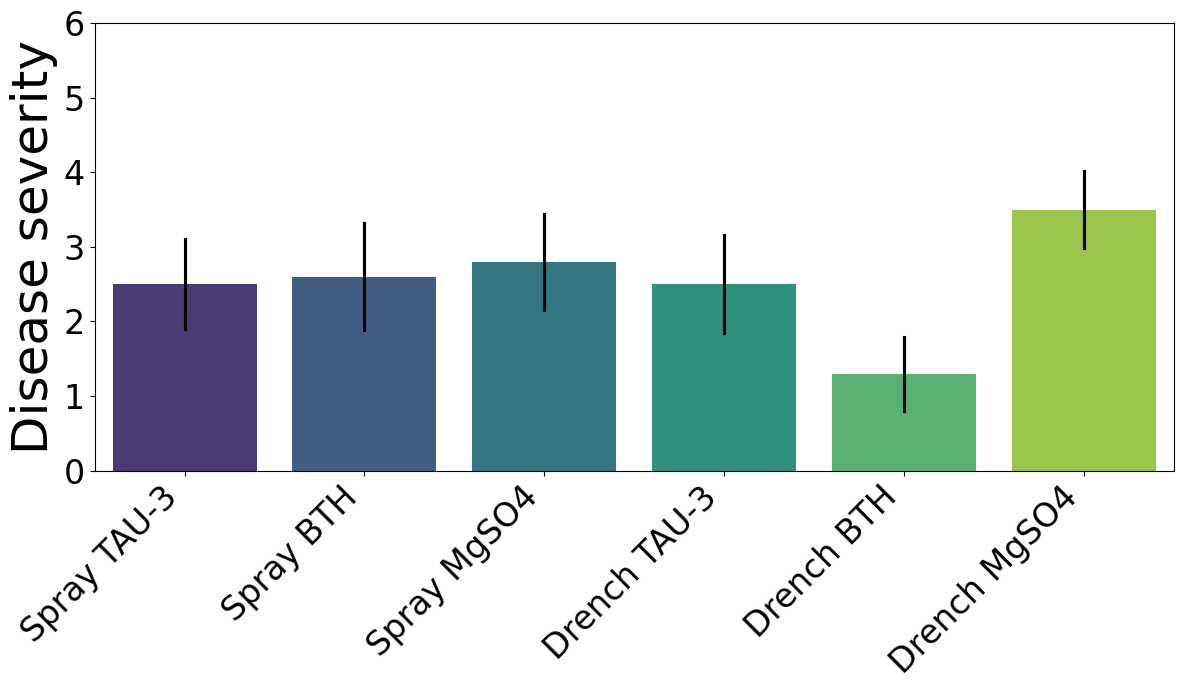

In [ ]:
# Define the custom treatment order (assuming same order or as observed from df_rs01)
custom_treatment_order_rs01 = ['Spray TAU-3', 'Spray BTH', 'Spray MgSO4', 'Drench TAU-3', 'Drench BTH', 'Drench MgSO4']

# Call the create_bar_plot function with df_melted_rs01
create_bar_plot(df_melted_rs01, custom_treatment_order_rs01,
                y_axis_title='Disease severity',
                y_axis_limit=6) # Adjust y-axis limit as needed for this data

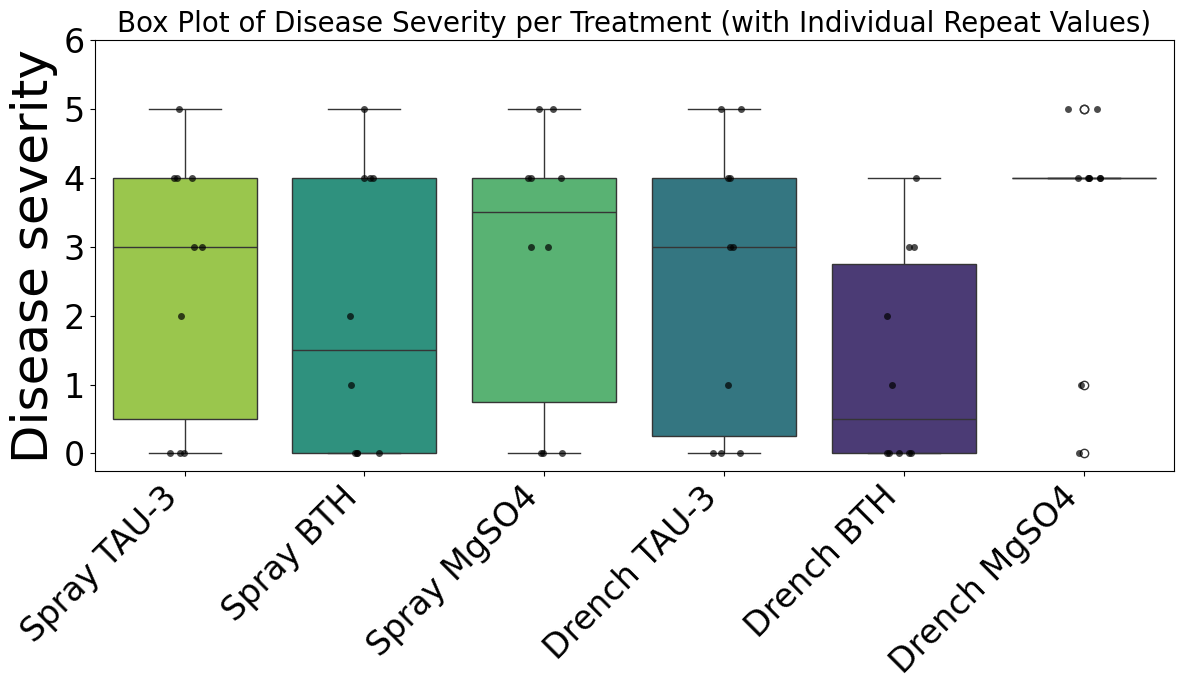

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정 (이 부분은 주석 처리된 상태로 유지합니다)
# Colab에서 한글 폰트를 사용하려면 폰트를 설치하고 경로를 지정해야 합니다.
# 예를 들어, 나눔 고딕 폰트를 사용하는 경우:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf
# Colab 런타임을 재시작해야 적용될 수 있습니다.

# 현재 Colab 환경에서 사용 가능한 폰트 경로를 확인하여 적절한 폰트를 선택하세요.
# 일반적으로 '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' 또는 유사한 경로입니다.
# 이 예시에서는 설치된 나눔고딕을 가정하고 설정합니다.
# if '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' in [f.fname for f in fm.fontManager.ttflist]:
#     plt.rc('font', family='NanumBarunGothic')
#     plt.rcParams['axes.unicode_minus'] = False
# else:
#     print("한글 폰트(나눔고딕)가 설치되어 있지 않습니다. 기본 폰트로 표시됩니다.")

# 폰트가 설정되지 않았을 경우를 대비하여 기본적인 설정을 유지합니다.

plt.figure(figsize=(12, 7))

# Create the box plot
sns.boxplot(x='Treatment', y='Repeat_Value', data=df_melted_rs01,
            palette='viridis', order=custom_treatment_order_rs01, hue='Treatment', legend=False)

# Overlay individual data points (stripplot)
sns.stripplot(x='Treatment', y='Repeat_Value', data=df_melted_rs01,
              jitter=True, color='black', size=5, alpha=0.7,
              order=custom_treatment_order_rs01)

plt.xlabel('')
plt.ylabel('Disease severity', fontsize=36)
plt.xticks(rotation=45, ha='right', fontsize=24)
plt.yticks(fontsize=24)
plt.ylim(top=6) # Set y-axis limit consistent with previous plot
plt.title('Box Plot of Disease Severity per Treatment (with Individual Repeat Values)', fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
# Filter data for 'Drench MgSO4'
drench_mgso4_data = df_melted_rs01[df_melted_rs01['Treatment'] == 'Drench MgSO4']['Repeat_Value']

# Calculate descriptive statistics for 'Drench MgSO4'
median_val = drench_mgso4_data.median()
q1_val = drench_mgso4_data.quantile(0.25)
q3_val = drench_mgso4_data.quantile(0.75)
min_val = drench_mgso4_data.min()
max_val = drench_mgso4_data.max()

print(f"'Drench MgSO4' Treatment Data:\n{drench_mgso4_data.tolist()}\n")
print(f"Minimum: {min_val}")
print(f"Q1 (25th percentile): {q1_val}")
print(f"Median (50th percentile): {median_val}")
print(f"Q3 (75th percentile): {q3_val}")
print(f"Maximum: {max_val}")

if q1_val == median_val and q3_val == median_val:
    print("\nQ1, Median, and Q3 are all the same. This means the majority of the data points, or a significant portion, have the same value, causing the box to collapse into a line.")
elif q1_val == median_val:
    print("\nQ1 and the Median are the same. This indicates that at least 50% of the data points are equal to or above the median value, making the lower part of the box collapse.")
elif q3_val == median_val:
    print("\nQ3 and the Median are the same. This indicates that at least 50% of the data points are equal to or below the median value, making the upper part of the box collapse.")
else:
    print("\nQ1, Median, and Q3 are distinct, but the range might be very small, or the data points might be clustered, making the box appear very narrow.")

'Drench MgSO4' Treatment Data:
[4, 4, 5, 4, 1, 0, 4, 4, 5, 4]

Minimum: 0
Q1 (25th percentile): 4.0
Median (50th percentile): 4.0
Q3 (75th percentile): 4.0
Maximum: 5

Q1, Median, and Q3 are all the same. This means the majority of the data points, or a significant portion, have the same value, causing the box to collapse into a line.


In [ ]:
# Display descriptive statistics for the entire df_rs01 dataset
display(df_rs01.describe())

,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6,repeat7,repeat8,repeat9,repeat10
count,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,3.00000,3.333333,3.333333,1.333333,2.500000,1.500000,2.166667,2.666667,1.833333,2.666667
std,1.67332,1.751190,1.966384,1.751190,2.428992,1.974842,2.041241,1.505545,2.228602,2.160247
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.00000,3.250000,2.500000,0.000000,0.250000,0.000000,0.250000,2.250000,0.000000,0.750000
50%,3.00000,4.000000,4.000000,0.500000,2.500000,0.500000,2.500000,3.000000,1.000000,3.500000
75%,3.75000,4.000000,4.750000,2.500000,4.750000,3.250000,4.000000,3.750000,3.500000,4.000000
max,5.00000,5.000000,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,5.000000


In [ ]:
print(f"df_rs01 데이터의 ANOVA P-값: {p_value_rs01:.3f}")

df_rs01 데이터의 ANOVA P-값: 0.193
